## Imports

In [262]:
import numpy as np
import pandas as pd
import yfinance as yf
from dateutil import relativedelta
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Global Settings

In [265]:
CONF_LEVEL = 95
TIME_HORIZEN = 1
TRADING_DAYS = 252

#Monte Carlo Settings 
MC_SIMULATIONS = 5000
MC_Days = 252
MC_PATHS = 50 # Num of paths to display on plot

## Utils

In [268]:
# converts all to float 
def _to_float(x):
    try:
        return float(np.asarray(x).reshape(-1)[0])
    except Exception:
        return float(x)

# Natural resources often have multiple tickers, this finds the first working one:
def first_available_ticker(candidates, start="2015-01-01"):
    for c in candidates:
        df = yf.download(c, start=start, auto_adjust=True, progress=False)
        if df is not None and not df.empty:
            return c
    raise ValueError(f"No data found for any of: {candidates}")

## Base Class

In [271]:
class FinancialInstrument:
    #Apply attributes to objects 
    def __init__(self, name: str, identifier: str, conf_level: float, time_horizen: int):
        self.name = name
        self.identifier = identifier
        self.conf_level = conf_level
        self.time_horizen = time_horizen

        #Set to None to be filled later
        self.prices = None
        self.returns = None
        self.total_return = None
        self.mu = None
        self.sigma = None
        self.var = None
        self.cvar = None
       

    def __str__(self):
        txt = f"{self.name} ({self.identifier})\n"
        txt += "=" * 100 + "\n"
        return txt
        
    #Calculates Historical Value At Risk, takes array and returns percentage
    def calc_var(self, returns: np.array) -> float:
        return np.percentile(returns, 100 - self.conf_level) * np.sqrt(self.time_horizen)
        
    #Calculates conditional Value A Risk scaled by sqrt(h)
    def calc_cvar(self, returns: np.array, VaR: float) -> float:
        mask = returns <= VaR
        return returns[mask].mean() * np.sqrt(self.time_horizen)

#Initialize Monte carlo methods
    def monte_carlo_sim(self):
        if self.returns is None or len(self.returns) == 0:
            raise ValueError("No return data available")
    
        # Annualized parameters
        daily_mu = self.mu / TRADING_DAYS
        daily_sigma = self.sigma / np.sqrt(TRADING_DAYS)
        
        # Extract last price
        last_price = self.prices['close'].iloc[-1]
        
        # Initialize simulation array
        self.mc_simulations = np.zeros((MC_SIMULATIONS, MC_Days))
        
        dt = 1  # daily step
        
        for i in range(MC_SIMULATIONS):
            # Generate random shocks
            random_shocks = np.random.normal(0, 1, MC_Days)
            price_path = np.zeros(MC_Days)
            price_path[0] = last_price  # initial value
            
            for t in range(1, MC_Days):
                drift = (daily_mu - 0.5 * daily_sigma**2) * dt
                shock = daily_sigma * np.sqrt(dt) * random_shocks[t-1]
                price_path[t] = price_path[t-1] * np.exp(drift + shock)
            
            self.mc_simulations[i] = price_path
        
        # Calculate final prices and MC VaR/CVaR
        self.mc_final_prices = self.mc_simulations[:, -1]
        mc_returns = (self.mc_final_prices / last_price) - 1
        self.mc_var = np.percentile(mc_returns, 100 - self.conf_level)
        
        # Calculate CVaR (average of losses worse than VaR)
        losses_below_var = mc_returns <= self.mc_var
        self.mc_cvar = mc_returns[losses_below_var].mean() if any(losses_below_var) else 0
    
    #create monte carlo visualization 
    def plot_monte_carlo(self):
        if self.mc_simulations is None: 
            self.monte_carlo_sim()

        # Create figure - last subplot is table so use different specs
        fig = make_subplots(
            rows=2, cols=2,
            subplot_titles=(
                "Monte Carlo Simulation Paths",
                "Final Price Distribution",
                "Historical vs Monte Carlo Returns",
                f"VaR Comparison (Confidence: {self.conf_level}%)"
            ),
            specs=[[{}, {}],
                   [{}, {"type": "table"}]]
        )
        hist_color = "rgb(83,128,141)"
        mc_color = "rgb(214,39,40)"

        #Plot monte carlo paths 
        for i in range(min(MC_PATHS, len(self.mc_simulations))):
            fig.add_trace(
                go.Scatter(
                    y=self.mc_simulations[i],
                    mode='lines',
                    line=dict(width=0.5, color=mc_color.replace('rgb', 'rgba').replace(')', ',0.1)')),
                    showlegend=False
                ),
                row=1, col=1
            )

        # Add mean path
        mean_path = np.mean(self.mc_simulations, axis=0)
        fig.add_trace(
            go.Scatter(
                y=mean_path,
                mode='lines',
                line=dict(width=3, color='rgb(255,127,14)'),
                name='Mean Path'
            ),
            row=1, col=1
        )
        
        # Add line for current price
        current_price = self.prices['close'].iloc[-1]
        fig.add_hline(
            y=current_price,
            line=dict(color="black", width=2, dash="dash"),
            row=1, col=1
        )

        fig.update_xaxes(title_text="Trading Days", row=1, col=1)
        fig.update_yaxes(title_text="Price", row=1, col=1)

        #Final Price Distribution plot
        fig.add_trace(
            go.Histogram(
                x=self.mc_final_prices,
                nbinsx=50,
                marker_color=mc_color,
                opacity=0.7,
                name='Monte Carlo'
            ),
            row=1, col=2
        )

        # Add statistics lines
        mean_price = np.mean(self.mc_final_prices)
        median_price = np.median(self.mc_final_prices)
        
        fig.add_vline(
            x=mean_price,
            line=dict(color="rgb(255,127,14)", width=2),
            row=1, col=2
        )
        
        fig.add_vline(
            x=median_price,
            line=dict(color="green", width=2),
            row=1, col=2
        )
        
        fig.add_vline(
            x=current_price,
            line=dict(color="black", width=2, dash="dash"),
            row=1, col=2
        )
        
        fig.update_xaxes(title_text="Final Price", row=1, col=2)
        fig.update_yaxes(title_text="Frequency", row=1, col=2)

        #Comparison of returns 
        hist_returns = self.returns * 100
        mc_returns_pct = ((self.mc_final_prices / current_price) - 1) * 100
        
        fig.add_trace(
            go.Histogram(
                x=hist_returns,
                nbinsx=50,
                marker_color=hist_color,
                opacity=0.5,
                name='Historical'
            ),
            row=2, col=1
        )
        
        fig.add_trace(
            go.Histogram(
                x=mc_returns_pct,
                nbinsx=50,
                marker_color=mc_color,
                opacity=0.5,
                name='Monte Carlo'
            ),
            row=2, col=1
        )
        
        fig.update_xaxes(title_text="Returns (%)", row=2, col=1)
        fig.update_yaxes(title_text="Frequency", row=2, col=1)
        
        # Var comparisons plots 
        labels = ['Historical VaR', 'Monte Carlo VaR', 'Historical CVaR', 'Monte Carlo CVaR']
        values = [
            f"{self.var*100:.2f}%" if self.var is not None else "N/A",
            f"{self.mc_var*100:.2f}%" if self.mc_var is not None else "N/A",
            f"{self.cvar*100:.2f}%" if self.cvar is not None else "N/A",
            f"{self.mc_cvar*100:.2f}%" if self.mc_cvar is not None else "N/A"
        ]
        
        fig.add_trace(
            go.Table(
                header=dict(
                    values=['Metric', 'Value'],
                    fill_color='gray',
                    align='center'
                ),
                cells=dict(
                    values=[labels, values],
                    align='center'
                )
            ),
            row=2, col=2
        )
        
        # Update layout
        fig.update_layout(
            title=f"Monte Carlo Analysis: {self.name}",
            height=800,
            showlegend=True
        )
        
        fig.show()

        
    #Creates visualization for closing price
    def plot_prices(self):
        df = self.prices
        title = (
            f"<b>{self.name} ({self.identifier})</b><br>"
            f"Return: {float(self.mu)*100:.2f}% | "        # Return using mean daily return 
            f"Volatility: {float(self.sigma)*100:.2f}% | "  # Volatility using standard deviation
            f"TR:{float(self.total_return)*100:.2f}%"   #Culmative return
        )
        #define hover  tooltip 
        hover_temp = "Date:%{x}  Close:%{y:,.2f}"
        #Build plotly figure 
        fig = go.Figure(
            go.Scatter(
                x=df.index,
                y=df.close,
                line=dict(color="rgb(83,128,141)", width=2),
                fill="tozeroy",
                fillcolor="rgba(83,128,141,0.5)",
                hovertemplate=hover_temp,
            )
        )
        #set layout using template 
        fig.update_layout(
            template="plotly_white",
            title=title,
            yaxis_title="Closing Price",
            width=600,
            height=500,
        )
        fig.show()

    def plot_histograms(self):
        #Build title 
        title = (
            f"<b>{self.name} Historical VaR ({self.time_horizen} days)</b><br>"
            f"VaR:{float(self.var)*100:.2f}% | "
            f"CVaR:{float(self.cvar)*100:.2f}%"
        )
        #prepare return data 
        returns = self.returns * 100
        #calculate maximum and minimum return values 
        min_r = float(np.min(self.returns) * 100)
        max_r = float(np.max(self.returns) * 100)

        #Create histogram figure 
        fig = go.Figure(go.Histogram(x=returns, marker_color="rgba(83,128,141,0.8)"))
        fig.add_shape(type="rect", x0=min_r, x1=self.var * 100, y0=0, y1=1,        #shade CVar level
                      fillcolor="red", opacity=0.1)   
        fig.add_shape(type="rect", x0=self.var * 100, x1=max_r, y0=0, y1=1,
                      fillcolor="skyblue", opacity=0.1)
        fig.add_shape(type="line", x0=self.var * 100, x1=self.var * 100, y0=0, y1=1,      #Draw Var line 
                      line=dict(color="rgba(255,51,51,.5)"))

        #set layout using template 
        fig.update_layout(template="plotly_white", width=600, height=500, title=title)
        fig.update_shapes(dict(xref="x", yref="paper"))
        fig.show()

## Security

In [274]:
#build security 
class Security(FinancialInstrument):
    #initilized stats to be computed 
    def __init__(self, name: str, identifier: str, conf_level: int, time_horizen: int):
       
        #apply attributes to objects  
        self.name = name
        self.identifier = identifier    
        self.conf_level = conf_level
        self.time_horizen = time_horizen

        self.prices = None
        self.returns = None
        self.total_return = None
        self.mu = None
        self.sigma = None
        self.var = None
        self.cvar = None
        # Monte Carlo attributes
        self.mc_simulations = None
        self.mc_final_prices = None
        self.mc_var = None
        self.mc_cvar = None

    def __str__(self):
    
        # create header
        txt = f"{self.name} ({self.identifier})\n"
        txt += "=" * 100 + "\n"

        #use try  statement to catch errors incase nothing is found 
        try:
            
            #Get first and last dates 
            start = self.prices.index[0].date()
            end = self.prices.index[-1].date()

            #Compute differnece btween start and end dates and format time frames
            diff = relativedelta.relativedelta(end, start)
            freq = f"{diff.years}y {diff.months}m" if diff.years > 1 else f"{diff.days} days"
            txt += f"Date Range: {start} - {end} ({freq})\n" 

             # Append cumulative total return over the entire price history
            txt += f"Total Return: {self.total_return*100:.2f}%\n" 
             # Append annualized return and annualized volatility
            txt += f"Annualized Return: {self.mu*100:.2f}% | Vol: {self.sigma*100:.2f}%\n" 
             # Append Value-at-Risk and Conditional VaR for the chosen time horizon
            txt += f"VaR ({self.time_horizen}d): {self.var*100:.2f}% | CVaR: {self.cvar*100:.2f}%\n"
            if self.mc_var is not None:
                txt += "-" * 50 + "\n"
                txt += "Monte Carlo Simulation (1 year):\n"
                txt += f"MC VaR: {self.mc_var*100:.2f}% | MC CVaR: {self.mc_cvar*100:.2f}%\n"

        except:
            txt += "No price data yet\n"

        return txt

    #Calculate Annulized Geometric Returns 
    def calc_return(self):
        return np.prod(1 + self.returns) ** (TRADING_DAYS / len(self.returns)) - 1

    #Calculate Annulized Volitility 
    def calc_volatility(self):
        return np.std(self.returns) * np.sqrt(TRADING_DAYS)

    def calc_total_return(self):
        first = self.prices.index[0]
        last = self.prices.index[-1]
        return self.prices.loc[last, "close"] / self.prices.loc[first, "close"] - 1

    def get_historical_price_data(self, from_="2010-01-01"):
        df = yf.download(self.identifier, start=from_, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise ValueError(f"No data returned for {self.identifier}")

        # Normalize DataFrame column names
        df = df.copy()

        # Create normalized column names
        normalized_columns = []
        for col in df.columns:
            # Convert to string to handle non-string column names
            col_str = str(col)
            
            # Convert to lowercase
            col_str = col_str.lower()
            
            # Replace spaces with underscores
            col_str = col_str.replace(" ", "_")
            
            # Remove leading/trailing underscores
            col_str = col_str.strip('_')
            
            # Replace multiple underscores with single underscore
            import re
            col_str = re.sub(r'_+', '_', col_str)
            
            # Ensure column name is not empty after normalization
            if not col_str:
                col_str = 'unnamed_column'
            
            # Handle duplicate column names
            if col_str in normalized_columns:
                counter = 1
                while f"{col_str}_{counter}" in normalized_columns:
                    counter += 1
                col_str = f"{col_str}_{counter}"
            
            normalized_columns.append(col_str)



        # find close price column
        close_col = None
        for col in ["close", "adj_close", "adjusted_close"]:
            if col in df.columns:
                close_col = col
                break

        if close_col is None and len(df.columns) > 0:
            close_col = df.columns[0]

        if close_col is None:
            raise ValueError(f"No price columns found for {self.identifier}")

        # create standardized df
        result_df = pd.DataFrame(index=df.index)
        result_df["close"] = df[close_col]
        result_df = result_df[~result_df.index.duplicated(keep="last")].sort_index()
        result_df["returns"] = result_df["close"].pct_change()

        # assign internal data
        self.prices = result_df
        self.returns = np.array(result_df["returns"].dropna())

        if len(self.returns) == 0:
            raise ValueError(f"No valid returns calculated for {self.identifier}")

        #calculate all statistics 
        self.mu = _to_float(self.calc_return())
        self.sigma = _to_float(self.calc_volatility())
        self.total_return = _to_float(self.calc_total_return())
        self.var = _to_float(self.calc_var(self.returns))
        self.cvar = _to_float(self.calc_cvar(self.returns, self.var))

## Example (Individual  Assets)

Gold ETF (GLD)
Date Range: 2015-01-02 - 2025-12-19 (10y 11m)
Total Return: 249.77%
Annualized Return: 12.12% | Vol: 14.68%
VaR (1d): -1.46% | CVaR: -2.08%

S&P500 (SPY)
Date Range: 2015-01-02 - 2025-12-19 (10y 11m)
Total Return: 297.79%
Annualized Return: 13.45% | Vol: 17.81%
VaR (1d): -1.68% | CVaR: -2.72%

MSCI EAFE (IEFA)
Date Range: 2015-01-02 - 2025-12-19 (10y 11m)
Total Return: 123.48%
Annualized Return: 7.62% | Vol: 17.23%
VaR (1d): -1.55% | CVaR: -2.54%




Running Monte Carlo for Gold ETF...



Running Monte Carlo for S&P500...


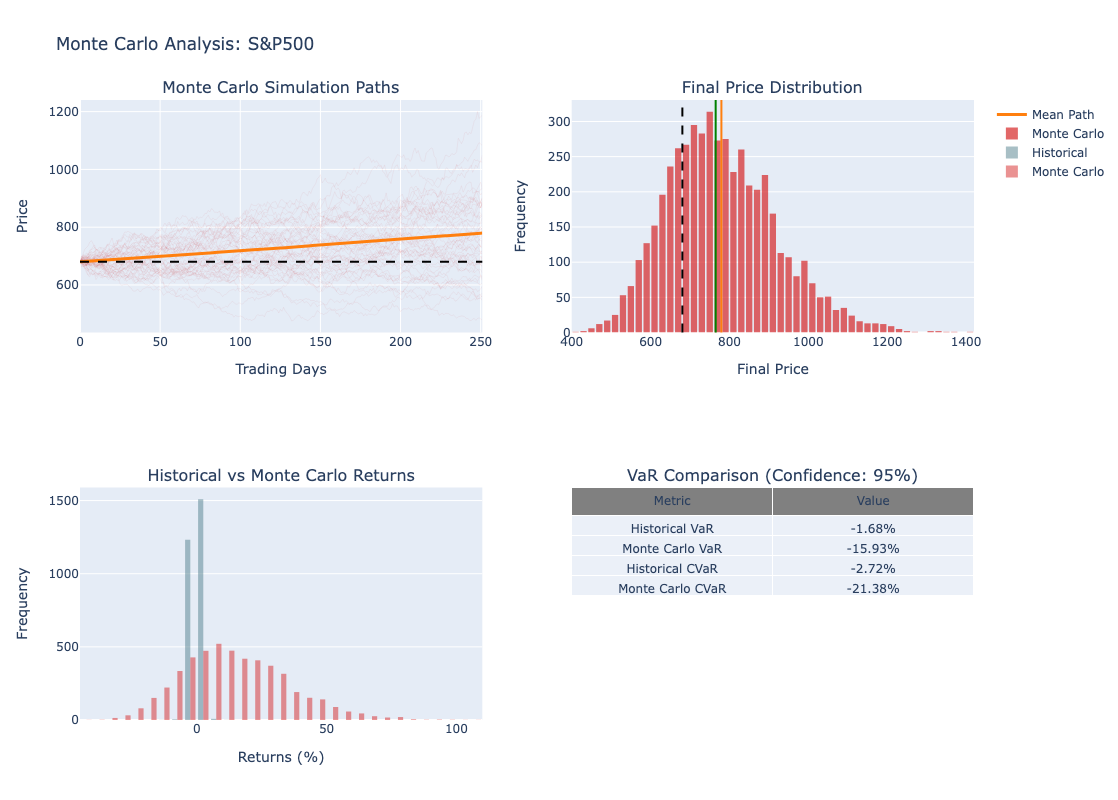


Running Monte Carlo for MSCI EAFE...


In [277]:
gold_candidates = ["GLD", "IAU", "XAUUSD=X", "GDX", "ABX.TO", "XGD.TO"]

gld = Security(
    name="Gold ETF",
    identifier=first_available_ticker(gold_candidates),
    conf_level=CONF_LEVEL,
    time_horizen=TIME_HORIZEN,
)
gld.get_historical_price_data(from_="2015-01-01")

spy = Security(
    name="S&P500",
    identifier="SPY",
    conf_level=CONF_LEVEL,
    time_horizen=TIME_HORIZEN,
)
spy.get_historical_price_data(from_="2015-01-01")

eafe = Security(
    name="MSCI EAFE",
    identifier="IEFA",
    conf_level=CONF_LEVEL,
    time_horizen=TIME_HORIZEN,
)
eafe.get_historical_price_data(from_="2015-01-01")

# Print results
print(gld)
print(spy)
print(eafe)

# Plots
gld.plot_prices()
gld.plot_histograms()
spy.plot_prices()
spy.plot_histograms()
eafe.plot_prices()
eafe.plot_histograms()

# Run Monte Carlo for each security and plot
for security in [gld, spy, eafe]:
    print(f"\nRunning Monte Carlo for {security.name}...")
    security.monte_carlo_sim()
    security.plot_monte_carlo()



## Portfolio 

In [279]:
class Portfolio(FinancialInstrument):
    def __init__(
        self,
        name,
        identifier,
        securities,
        weights,
        initial_value,
        conf_level,
        time_horizen,
    ):
        self.name = name
        self.identifier = identifier
        self.conf_level = conf_level
        self.time_horizen = time_horizen

        self.securities = securities
        self.weights = weights
        self.initial_value = initial_value

    def calc_portfolio_values(self, sec_returns):
        # Find the minimum common length of returns
        min_length = min(len(returns) for returns in sec_returns)
        
        # Trim all return arrays to the same length
        trimmed_returns = [returns[-min_length:] for returns in sec_returns]
        
        p_returns = np.dot(np.array(trimmed_returns).T, self.weights)
        p_values = np.cumprod(1 + p_returns) * self.initial_value
        p_values = np.insert(p_values, 0, self.initial_value)

        p_total = (1 + p_returns).prod() - 1
        p_mu = (1 + p_total) ** (TRADING_DAYS / len(p_returns)) - 1
        p_sigma = np.std(p_returns) * np.sqrt(TRADING_DAYS)

        return p_values, p_returns, p_total, p_mu, p_sigma
        
    #Update values 
    def update_portfolio_values(self):
        sec_returns = [sec.returns for sec in self.securities]
        p_values, p_returns, p_total, p_mu, p_sigma = self.calc_portfolio_values(sec_returns)

        self.prices = pd.DataFrame({"close": p_values})
        self.returns = p_returns
        self.total_return = _to_float(p_total)
        self.mu = _to_float(p_mu)
        self.sigma = _to_float(p_sigma)
        self.var = _to_float(super().calc_var(p_returns))
        self.cvar = _to_float(super().calc_cvar(p_returns, self.var))



## Build Portfolio & Plot

In [281]:
#build portfolio plot
portfolio = Portfolio(
    name="Equity Portfolio",
    identifier="PORT1",
    securities=[spy, gld, eafe],
    weights=[0.33, 0.33, 0.33],
    initial_value=100000,
    conf_level=CONF_LEVEL,
    time_horizen=TIME_HORIZEN,
)

portfolio.update_portfolio_values()
portfolio.plot_prices()
portfolio.plot_histograms()

print(portfolio)

print("\n" + "="*100)
print("RUNNING MONTE CARLO SIMULATIONS")
print("="*100)

# Run Monte Carlo for portfolio
print("\nRunning Monte Carlo for Portfolio...")
portfolio.monte_carlo_sim()
portfolio.plot_monte_carlo()

Equity Portfolio (PORT1)


RUNNING MONTE CARLO SIMULATIONS

Running Monte Carlo for Portfolio...
